In [2]:
# Amazon Prime Video Content Analysis
### Data Cleaning and Preprocessing

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns 
pd.set_option('display.max_columns', None)

In [4]:
# Load the Dataset

In [5]:
df = pd.read_csv(r"C:\Users\shris\Downloads\amazon_prime_titles.csv.zip")

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [7]:
# Understanding the Dataset

In [8]:
df.shape

(9668, 12)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [11]:
df.describe()

,release_year
count,9668.000000
mean,2008.341849
std,18.922482
min,1920.000000
25%,2007.000000
50%,2016.000000
75%,2019.000000
max,2021.000000


In [12]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
623,s624,Movie,The Hidden Secrets: Gangsters of the 1920s and...,Ted Hallock,"Al Capone, Bonnie Parker, Clyde Barrow, John D...",NaN,NaN,2012,13+,69 min,Documentary,"Never before has a gallery of cops, robbers, a..."
3016,s3017,TV Show,Bo on the Go,NaN,NaN,NaN,NaN,2009,TV-Y7,3 Seasons,"Animation, Kids","Bo is a positive, super-energetic and inquisit..."
6101,s6102,Movie,Anu and Arjun(Kannada),Jeffrey Gee Chin,"Vishnu Manchu, Kajal Aggarwal, Suniel Shetty, ...",NaN,NaN,2021,13+,133 min,"Action, Drama",Based on a series of true incidents that shook...
922,s923,TV Show,SpongeBob DocuPants,NaN,NaN,NaN,NaN,2020,TV-PG,1 Season,"Drama, Kids",Imagine classic SpongeBob moments being told t...
4859,s4860,Movie,A Hug,DF Fiuza,NaN,NaN,NaN,2020,16+,94 min,Drama,A group of professors has to fight the governm...


In [13]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [14]:
df[['country', 'date_added']].head(20)

,country,date_added
0,Canada,"March 30, 2021"
1,India,"March 30, 2021"
2,United States,"March 30, 2021"
3,United States,"March 30, 2021"
4,United Kingdom,"March 30, 2021"
5,United Kingdom,"March 30, 2021"
6,United States,"March 30, 2021"
7,United States,"March 30, 2021"
8,Canada,"March 30, 2021"
9,United States,"April 1, 2021"


In [15]:
df['country'].value_counts().head()

country
United States                    253
India                            229
United Kingdom                    28
Canada                            16
United Kingdom, United States     12
Name: count, dtype: int64

In [16]:
df['date_added'].value_counts().head()

date_added
March 30, 2021        14
August 27, 2021        6
June 11, 2021          4
October 2, 2021        4
September 26, 2021     4
Name: count, dtype: int64

In [17]:
# Data Cleaning

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [20]:
df.isnull().sum() / len(df)*100

show_id          0.000000
type             0.000000
title            0.000000
director        21.545304
cast            12.753413
country         93.049235
date_added      98.396773
release_year     0.000000
rating           3.485726
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [21]:
# Handling Missing Values

In [22]:
# Fill missing values in director and cast

df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')

In [23]:
# Fill missing values in rating using mode

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [24]:
# Drop date_added column

df.drop('date_added',axis=1, inplace=True)

In [25]:
df.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country         8996
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [26]:
# Checking Data Types

In [27]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [28]:
df.nunique()

show_id         9668
type               2
title           9668
director        5774
cast            7928
country           86
release_year     100
rating            24
duration         219
listed_in        518
description     9414
dtype: int64

In [29]:
df['type'].value_counts()

type
Movie      7814
TV Show    1854
Name: count, dtype: int64

In [30]:
df['rating'].value_counts()

rating
13+         2454
16+         1547
ALL         1268
18+         1243
R           1010
PG-13        393
7+           385
PG           253
NR           223
TV-14        208
TV-PG        169
TV-NR        105
G             93
TV-G          81
TV-MA         77
TV-Y          74
TV-Y7         39
UNRATED       33
NC-17          3
AGES_18_       3
NOT_RATE       3
AGES_16_       2
16             1
ALL_AGES       1
Name: count, dtype: int64

In [31]:
df['listed_in'].value_counts().head(10)

listed_in
Drama                            986
Comedy                           536
Drama, Suspense                  399
Comedy, Drama                    377
Animation, Kids                  356
Documentary                      350
Kids                             334
Action, Drama                    297
Documentary, Special Interest    296
TV Shows                         263
Name: count, dtype: int64

In [32]:
df['release_year'].describe()

count    9668.000000
mean     2008.341849
std        18.922482
min      1920.000000
25%      2007.000000
50%      2016.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [33]:
df['director'].value_counts().head(10)

director
unknown                  2083
Mark Knight               113
Cannis Holder              61
Moonbug Entertainment      37
Jay Chapman                34
Arthur van Merwijk         30
Manny Rodriguez            22
John English               20
1                          16
Brian Volk-Weiss           15
Name: count, dtype: int64

In [34]:
df['country'].value_counts().head(10)

country
United States                    253
India                            229
United Kingdom                    28
Canada                            16
United Kingdom, United States     12
Spain                              8
Italy                              8
Canada, United States              7
United States, United Kingdom      6
India, United States               5
Name: count, dtype: int64

In [35]:
# Visualization 1: Movies vs TV Shows

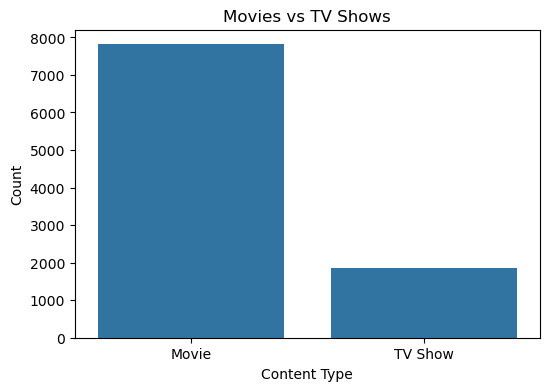

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

In [37]:
# Visualization 2: Top 10 Ratings

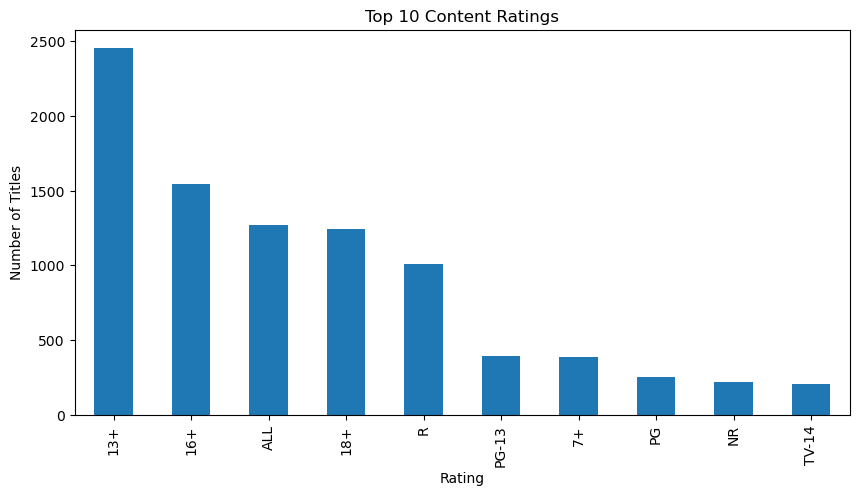

In [38]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.show()

In [39]:
# Visualization 3: Top 10 Genres

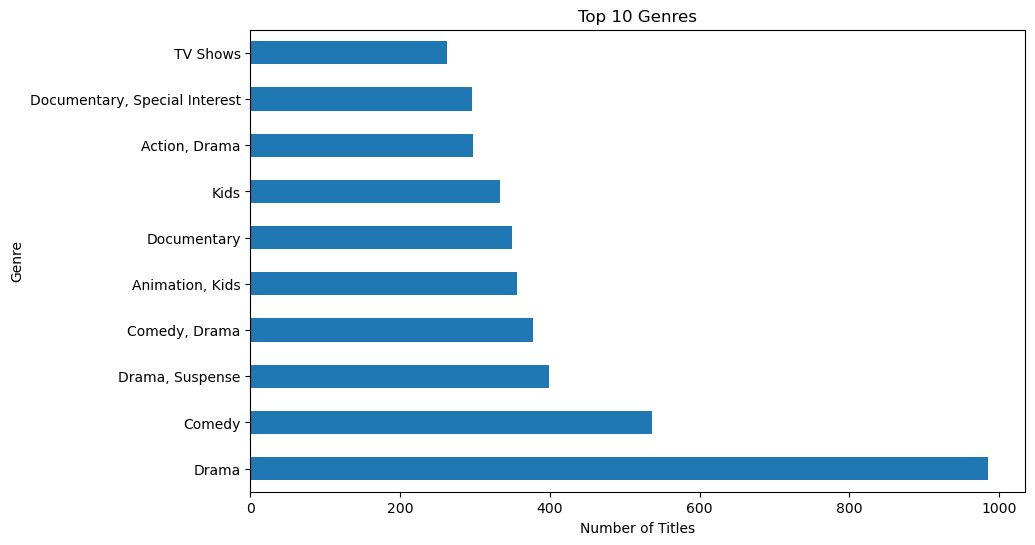

In [40]:
plt.figure(figsize=(10,6))

df['listed_in'].value_counts().head(10).plot(kind='barh')

plt.title('Top 10 Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

In [41]:
# Visualization 4: Release Year Distribution

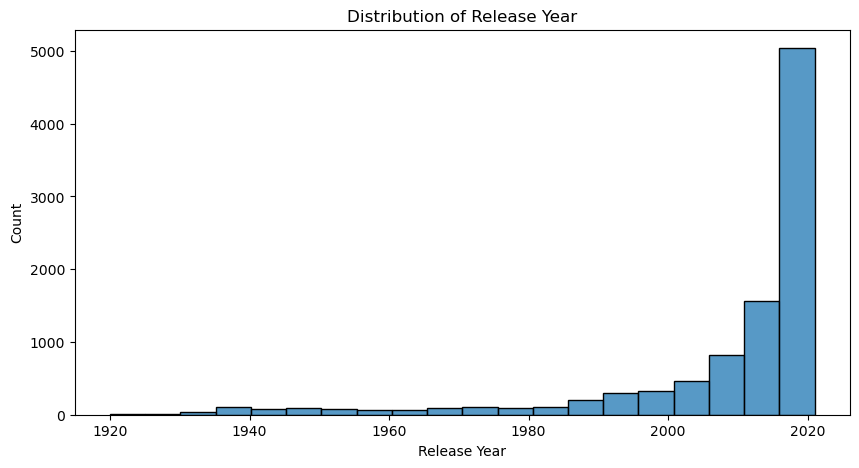

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=20)

plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

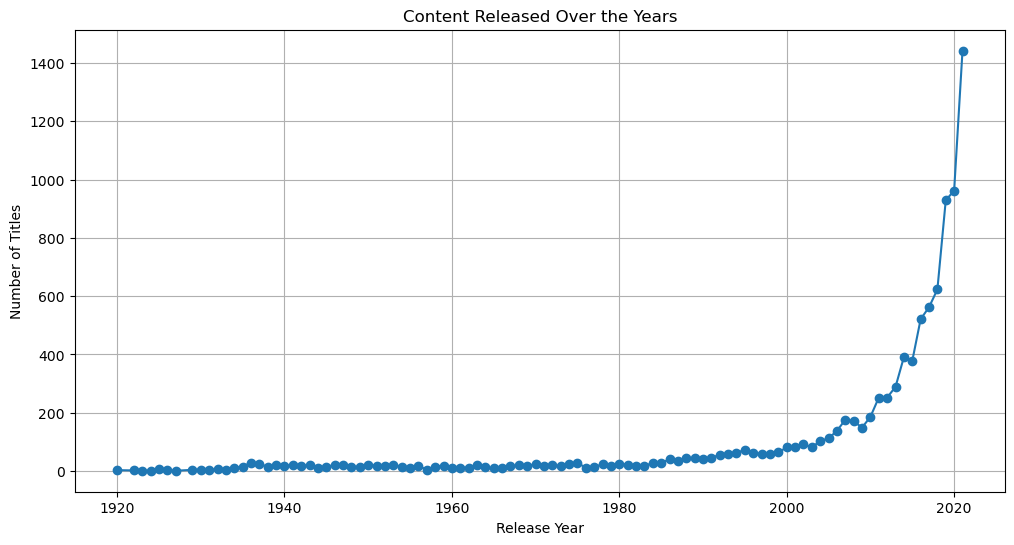

In [43]:
plt.figure(figsize=(12,6))

release = df['release_year'].value_counts().sort_index()

plt.plot(release.index, release.values, marker='o')

plt.title('Content Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

In [44]:
# Visualization 6: Top 10 Directors

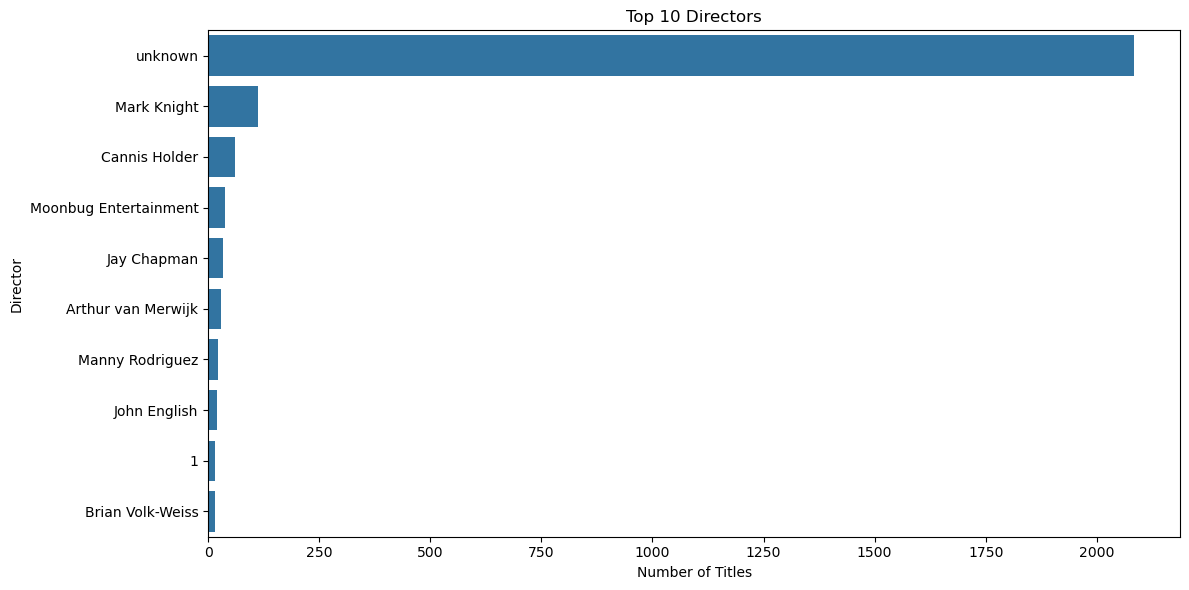

In [45]:
plt.figure(figsize=(12,6))

top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title('Top 10 Directors')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.tight_layout()

plt.show()

In [46]:
# Visualization 7: Top 10 Countries

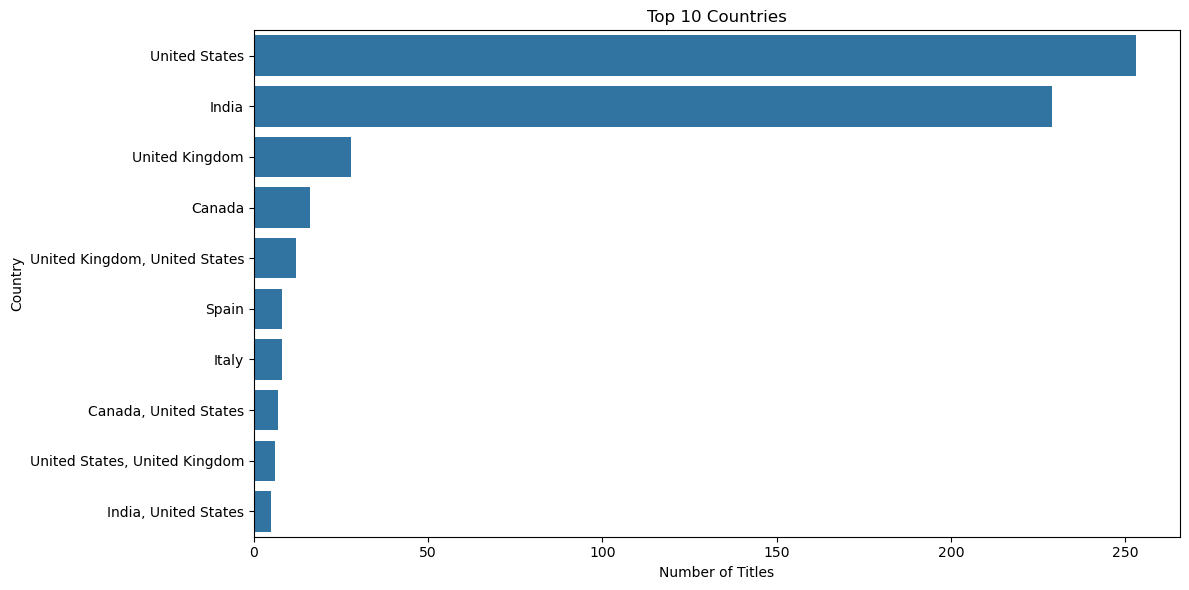

In [47]:
plt.figure(figsize=(12,6))

top_country = df['country'].dropna().value_counts().head(10)

sns.barplot(x=top_country.values, y=top_country.index)

plt.title('Top 10 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()

plt.show()

In [48]:
# Save Cleaned Dataset

In [49]:
df.to_csv("amazon_prime_cleaned.csv", index=False)

In [50]:
df.to_csv("amazon_prime_cleaned_utf8.csv", index=False, encoding="utf-8-sig")

In [52]:
df.shape

(9668, 11)

In [53]:
df.head(3)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2014,13+,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2017,13+,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...


In [54]:
df.to_csv(
    "amazon_prime_final.tsv",
    sep="\t",
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)